In [1]:
import hoda
import tensorly as tl

print(tl.get_backend())
%pip install toeplitzlda
%pip freeze | grep moabb

cupy
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.8/292.8 kB 3.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.12.2
    Uninstalling seaborn-0.12.2:
      Successfully uninstalled seaborn-0.12.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moabb 1.0.0 requires seaborn<0.13.0,>=0.12.1, but you have seaborn 0.11.2 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
moabb==1.0.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation
tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
    #BI2012(),
    #BI2013a(),
    #BI2014a(),
    #BI2014b(),
    #BI2015a(),
    #BI2015b(),
    BNCI2014_008(),
    #BNCI2014_009(),
    #BNCI2015_003(),
    #Cattan2019_VR(),
    #EPFLP300(),
    #Huebner2017(),
    #Huebner2018(),
    #Lee2019_ERP(),
    #Sosulski2019(),
]

evaluation = WithinSessionEvaluation(
    paradigm=paradigm,
    datasets=datasets,
    suffix="hoda_erp",
    overwrite=True,
    random_state=42,
    n_jobs=5,
)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/usr/local/lib/python3.10/dist-packages/moabb/analysis/results.py:93: RuntimeWarning: Setting non-standard config type: "MOABB_RESULTS"
  set_config("MOABB_RESULTS", osp.join(osp.expanduser("~"), "mne_data"))


In [3]:
from sklearn.pipeline import make_pipeline, Pipeline
from hoda.hoda import HODA, BTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from hoda.classification import Vectorize, SelectFweAtLeastOne, ToeplitzLDAWrapper
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from hoda.tensorize import hankel_tensor

pipelines = dict()

hoda_params=dict(
    max_iter=128,
    tol=1e-16,
    init ='mlsvd',
    shrinkage='lw',
    toeplitz=(1,),
    obj='rt',
    solver='lobpcg',
    taper=False,
    extra_train_info=False,
    verbose=False,  
)

pipelines['sLDA'] = make_pipeline(
        Vectorize(),
        LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)
pipelines['tLDA'] = ToeplitzLDAWrapper()

pipelines['HODA_full'] =Pipeline([
        ('hoda', HODA(
            rank=None,
            **hoda_params
        )),
        ('vec', Vectorize()),
        ('lda', LinearDiscriminantAnalysis())
    ])

"""
pipelines['HODA'] = GridSearchCV(
    Pipeline([
        ('hoda', HODA(
            **hoda_params
        )),
        ('vec', Vectorize()),
        ('lda', LinearDiscriminantAnalysis())
    ]),
    dict(hoda__rank=list(range(1,8+1))),
    scoring='roc_auc',
)
"""


"\npipelines['HODA'] = GridSearchCV(\n    Pipeline([\n        ('hoda', HODA(\n            **hoda_params\n        )),\n        ('vec', Vectorize()),\n        ('lda', LinearDiscriminantAnalysis())\n    ]),\n    dict(hoda__rank=list(range(1,8+1))),\n    scoring='roc_auc',\n)\n"

In [4]:
#import warnings
#warnings.filterwarnings("ignore")

results = evaluation.process(pipelines)

BNCI2014-008-WithinSession:   0%|                                                               | 0/8 [00:00<?, ?it/s]

No hdf5_path provided, models will not be saved.


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:312: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  12%|██████▉                                                | 1/8 [00:09<01:06,  9.51s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:312: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


...

BNCI2014-008-WithinSession:  75%|█████████████████████████████████████████▎             | 6/8 [00:37<00:11,  5.75s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:312: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  88%|████████████████████████████████████████████████▏      | 7/8 [00:43<00:05,  5.73s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:312: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession: 100%|███████████████████████████████████████████████████████| 8/8 [00:48<00:00,  6.10s/it]


In [5]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.843990,0.048569,4200.0,1,0,8,1,BNCI2014-008,tLDA
1,0.820810,0.044531,4200.0,2,0,8,1,BNCI2014-008,tLDA
2,0.892798,0.042186,4200.0,3,0,8,1,BNCI2014-008,tLDA
3,0.815190,0.039875,4200.0,4,0,8,1,BNCI2014-008,tLDA
4,0.866292,0.039840,4200.0,5,0,8,1,BNCI2014-008,tLDA
5,0.899024,0.039930,4200.0,6,0,8,1,BNCI2014-008,tLDA
6,0.882051,0.040193,4200.0,7,0,8,1,BNCI2014-008,tLDA
7,0.954788,0.040060,4200.0,8,0,8,1,BNCI2014-008,tLDA
8,0.844222,0.417886,4200.0,1,0,8,1,BNCI2014-008,HODA_full
9,0.833502,0.238678,4200.0,2,0,8,1,BNCI2014-008,HODA_full


(0.5, 1.0)

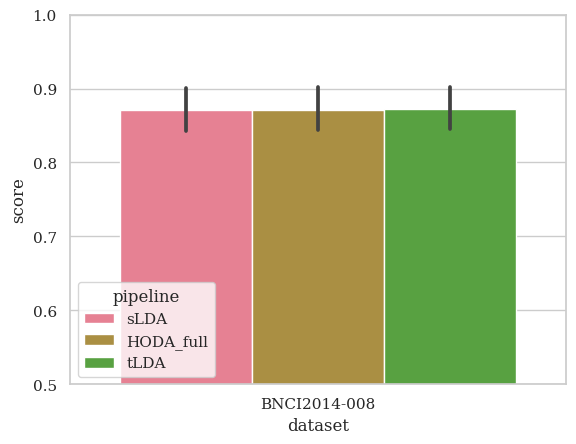

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()

sns.barplot(
     data=results,
    y="score", x="dataset", hue="pipeline", hue_order=order.index,
)
plt.ylim([.5,1])

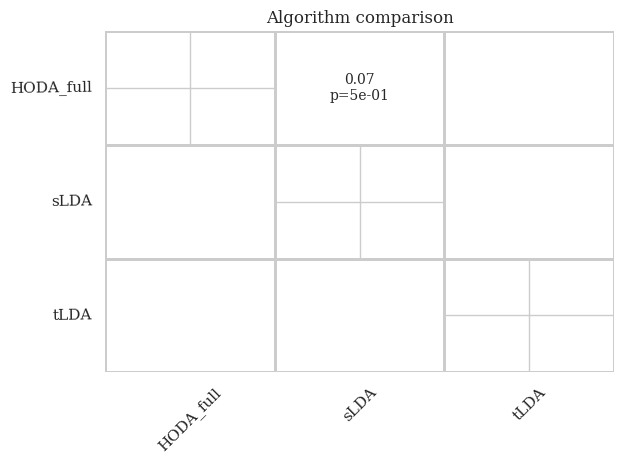

In [7]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)

In [8]:
from moabb.analysis.plotting import meta_analysis_plot, paired_plot
_ = meta_analysis_plot(stats, 'HODA', 'tLDA')
_  = paired_plot(results, 'HODA', 'tLDA')

AssertionError: 